# ÉquiAlgo : rapport d'audit et de correction du biais régional

Ce carnet raconte, dans l'ordre : (a) le diagnostic du biais, (b) la définition de l'équité retenue, (c) la chaîne de correction et ses chiffres finaux, (d) les garde-fous, (e) le front de Pareto, (f) les pistes rejetées, (g) les limites.

Les calculs appellent les fonctions du dépôt (`src.policy`, `src.monitoring`, `src.evaluation`) ; rien n'y est réimplémenté. Les chiffres finaux sont lus dans `decision_record.json`. Tout vient de l'historique des 10 000 demandes : aucun score externe n'entre dans la chaîne. Données synthétiques, graines fixes.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import json, time
T0 = time.time()
import numpy as np, pandas as pd
from IPython.display import Image, display
from src.policy import (CommitteeModel, DECLARED_INCOME_WEIGHT, REVIEWER_INCOME_WEIGHTS, auc, budget_share,
                        correction_report, is_remote, reference_weights)
from src.monitoring.checks import proxy_auc

pd.set_option('display.width', 200); pd.set_option('display.max_columns', 30)
history = pd.read_csv('data/donnees_demandes.csv')
batch = pd.read_csv('data/candidats_evaluation.csv')
record = json.load(open('decision_record.json'))
y = history['decision_octroi'].to_numpy()
remote = is_remote(history)
share = budget_share(history)
print(f"{len(history):,} dossiers historiques, {remote.sum():,} en région éloignée ; part historique d'octrois {share:.2%}")

10,000 dossiers historiques, 4,000 en région éloignée ; part historique d'octrois 39.94%


## (a) Diagnostic : le comité pénalise la région

Le modèle du comité (régression logistique sur 8 critères légitimes + indicateur « région éloignée ») sert **au diagnostic**, et à estimer le rapport heures / cote R. `correction_report` donne la pénalité, son intervalle de confiance par rééchantillonnage et le test d'égalité des pentes entre régions.

In [2]:
report = correction_report(history, share)
rates = pd.Series(y).groupby(remote).mean()
print(f"Taux historique d'octroi : centre {rates[0]:.1%}, éloigné {rates[1]:.1%}")
print(f"Pénalité régionale : {report.penalty:.2f} logit, IC 95 % [{report.penalty_ci[0]:.2f} ; {report.penalty_ci[1]:.2f}] (cotes x {np.exp(report.penalty):.2f})")
print(f"Test des mêmes pentes : khi² = {report.slope_test_statistic:.2f}, ddl = {report.slope_test_df}, p = {report.slope_test_p:.2f}"
      "  -> p élevé : une pénalité plate, pas des règles différentes par région")

Taux historique d'octroi : centre 48.4%, éloigné 27.3%
Pénalité régionale : -1.90 logit, IC 95 % [-2.07 ; -1.73] (cotes x 0.15)
Test des mêmes pentes : khi² = 4.38, ddl = 8, p = 0.82  -> p élevé : une pénalité plate, pas des règles différentes par région


### Variables proxys de la région

Pouvoir de chaque variable pour prédire « région éloignée » (AUC, 0,5 = aucun, 1 = parfait). Le code postal est encodé par son taux éloigné sur une moitié de l'échantillon et évalué sur l'autre.

In [3]:
half = np.random.default_rng(0).random(len(history)) < 0.5
postal_rate = pd.Series(remote[half]).groupby(history['code_postal_3'][half].to_numpy()).mean()
postal_score = history['code_postal_3'][~half].map(postal_rate).fillna(0.5).to_numpy()
columns = {'code postal (3 car.)': None, 'distance au campus': 'distance_domicile_campus_km',
           'heures de travail': 'heures_travail_semaine', 'revenu familial': 'revenu_familial_estime',
           'cote R': 'cote_r_equivalent'}
rows = {}
for label, column in columns.items():
    score = postal_score if column is None else history[column].to_numpy()
    truth = remote[~half] if column is None else remote
    a = auc(truth, score)
    rows[label] = max(a, 1 - a)
proxies = pd.Series(rows, name='AUC région').sort_values(ascending=False)
print(proxies.round(3).to_string())
print(f"\nAUC (validation croisée) du modèle sur les trois variables de score (cote R, revenu, heures) : {proxy_auc(history):.3f}")

code postal (3 car.)    1.000
distance au campus      0.998
heures de travail       0.805
revenu familial         0.693
cote R                  0.561

AUC (validation croisée) du modèle sur les trois variables de score (cote R, revenu, heures) : 0.845


Retirer la colonne région ne suffit donc pas : code postal et distance l'encodent presque parfaitement ; les heures et le revenu en portent une grande part.

### Même cote R, issue différente

In [4]:
band = history[(history['cote_r_equivalent'] > 28) & (history['cote_r_equivalent'] <= 30)]
by_group = band.groupby(is_remote(band))['decision_octroi'].agg(['mean', 'size'])
by_group.index = ['Centre', 'Éloignée']
by_group['mean'] = (by_group['mean'] * 100).round(1)
print("Cote R dans ]28 ; 30] :")
print(by_group.rename(columns={'mean': "% d'octrois", 'size': 'dossiers'}).to_string())

Cote R dans ]28 ; 30] :
          % d'octrois  dossiers
Centre           70.9      1438
Éloignée         40.8       910


### Le revenu : une pénalité régionale cachée

Les candidats éloignés ont un revenu (log) plus bas. Comme le comité récompense le revenu, cette récompense désavantage mécaniquement la région. On mesure, **sur l'échelle du comité** (logit), la contribution moyenne de chaque critère à l'écart centre / éloigné, et on la compare à la pénalité explicite.

In [5]:
committee = CommitteeModel().fit(history, y)
from src.policy.schema import COMMITTEE_FEATURES, committee_features
Z = committee.scaler_.transform(committee_features(history))
coef = dict(zip(COMMITTEE_FEATURES, committee.lr_.coef_[0][:-1]))
shift = {name: Z[remote == 1, i].mean() - Z[remote == 0, i].mean() for i, name in enumerate(COMMITTEE_FEATURES)}
penalty = abs(committee.remote_penalty_)
table = pd.DataFrame({'décalage éloigné - centre (écart-types)': shift, 'contribution (logit)': {n: coef[n] * shift[n] for n in coef}})
table['part de la pénalité explicite'] = table['contribution (logit)'] / penalty
print(table.loc[['log_revenu', 'heures_travail', 'cote_r']].round(3).to_string())
print(f"\nPénalité explicite : {committee.remote_penalty_:.2f} logit. Le revenu coûte {coef['log_revenu'] * shift['log_revenu']:.2f} logit aux candidats éloignés, "
      f"soit {abs(coef['log_revenu'] * shift['log_revenu']) / penalty:.0%} de la pénalité. Les heures les aident de {coef['heures_travail'] * shift['heures_travail']:+.2f} logit.")

                décalage éloigné - centre (écart-types)  contribution (logit)  part de la pénalité explicite
log_revenu                                       -0.681                -0.543                         -0.286
heures_travail                                    1.064                 0.804                          0.423
cote_r                                           -0.220                -0.905                         -0.476

Pénalité explicite : -1.90 logit. Le revenu coûte -0.54 logit aux candidats éloignés, soit 29% de la pénalité. Les heures les aident de +0.80 logit.


## (b) Définition de l'équité : cinq examinateurs, un consensus

Cinq examinateurs indépendants (mérite, besoin, juridique, processus de données, équité régionale ; `docs/reviews/`) ont proposé chacun une règle de référence. Le consensus (`docs/reviews/CONSENSUS.md`) : cote R d'abord, heures en petit crédit, première génération 0 ; **égalité des chances, pas parité des taux**.

Le revenu est le seul point de désaccord : mérite, juridique et régional lui donnent 0, besoin −0,05, processus de données +0,19. Le poids retenu, **+0,025 (en unités de cote R)**, est un **choix de modélisation déclaré, retenu par essais, dans la plage de désaccord des examinateurs** (−0,05 à +0,19). Le poids des heures, **0,185**, est lui aussi un choix de modélisation déclaré, retenu par essais, proche du rapport heures / R de l'ajustement du comité (calculé à chaque exécution).

In [6]:
weights = pd.DataFrame(reference_weights(committee)).loc[['cote_r', 'heures_travail', 'log_revenu', 'premiere_generation']]
print("Poids des règles de référence (R = 1) :")
print(weights.round(4).to_string())
print(f"\nPoids déclaré des heures : {weights.loc['heures_travail', 'consensus']:.4f} ; rapport heures / R du comité : {committee.hours_over_r():.4f}")
print(f"Poids déclaré du revenu : {DECLARED_INCOME_WEIGHT} ; plage des examinateurs : {min(REVIEWER_INCOME_WEIGHTS.values())} à {max(REVIEWER_INCOME_WEIGHTS.values())}")

Poids des règles de référence (R = 1) :
                     consensus   merit    need   legal  data_process  regional
cote_r                   1.000  1.0000  1.0000  1.0000        1.0000    1.0000
heures_travail           0.185  0.1835  0.1835  0.1835        0.1835    0.1835
log_revenu               0.025  0.0000 -0.0500  0.0000        0.1900    0.0000
premiere_generation      0.000  0.0000  0.0000  0.0000        0.0000    0.0000

Poids déclaré des heures : 0.1850 ; rapport heures / R du comité : 0.1835
Poids déclaré du revenu : 0.025 ; plage des examinateurs : -0.05 à 0.19


## (c) Chaîne de correction et décision finale

```
historique (10 000) -> validation -> modèle du comité (diagnostic : pénalité, IC, rapport heures / R)
   -> base = règle de consensus : R + 0,185 x heures + 0,025 x log revenu  (unités de cote R)
   -> résidu TabM appris sur l'historique (Kaggle), artefact vérifié par SHA-256 ; ensemble de 4 TabM, mélange déclaré = 2,5
   -> score = base + résidu ; les k meilleurs candidats (k = part historique x n)
   -> jury (panel des cinq règles) et raisonnement en MODE AUDIT : votes, traces, contradictions enregistrés, aucun échange
   -> audit : surveillance + garde du jury + garde du consensus + garde forte
   -> au plus un décalage borné (|d| <= 0,10) ou BLOCAGE
   -> garde de sortie -> PUBLICATION ou BLOCAGE
```

Chiffres de la décision publiée (`decision_record.json`) :

In [7]:
regions = ['Montreal', 'Capitale-Nationale', 'Bas-Saint-Laurent', 'Cote-Nord', 'Gaspesie-Iles-de-la-Madeleine']
monitoring = {c['name']: c for c in record['verdicts'][0]['checks']}
print(f"Statut : {record['status']} ; octrois {record['grants']:,} sur {record['applicants']:,} ({record['grants'] / record['applicants']:.2%}) ; décalage {record['offset']:+.3f}")
print(f"Configuration : {record['config']['name']} ; mélange du résidu {record['config']['residual_blend']}")
print(f"Taux par région : " + ', '.join(f"{r} {record['region_rates'][r]:.1%}" for r in regions))
print(f"Jury (mode audit) : {record['jury']['triggered']} cas examinés, {record['jury']['overturned_out']} échanges contestés, aucun appliqué")
print(f"Raisonnement : {record['deliberation']}")
for name in ['demographic parity gap (centre vs remote)', 'impact ratio, lowest/highest region', 'opportunity gap vs merit reference']:
    c = monitoring[name]; print(f"  {name}: {c['value']:+.3f}  [{c['status']}]  {c['detail']}")

Statut : published ; octrois 1,598 sur 4,000 (39.95%) ; décalage +0.000
Configuration : declared: base + TabM ensemble residual ; mélange du résidu 2.5
Taux par région : Montreal 40.4%, Capitale-Nationale 39.7%, Bas-Saint-Laurent 38.1%, Cote-Nord 39.3%, Gaspesie-Iles-de-la-Madeleine 41.2%
Jury (mode audit) : 200 cas examinés, 26 échanges contestés, aucun appliqué
Raisonnement : {'examined': 200, 'proposed_moves': 6, 'moved_out': 0, 'moved_in': 0, 'contradicted_kept': 49, 'rounds': 0}
  demographic parity gap (centre vs remote): +0.005  [OK]  centre 40.1%, remote 39.7%
  impact ratio, lowest/highest region: +0.924  [OK]  Bas-Saint-Laurent 38.1% vs Gaspesie-Iles-de-la-Madeleine 41.2%
  opportunity gap vs merit reference: -0.060  [OK]  deserving = top R scores at the same budget; centre minus remote -0.0605, absolute 0.0605


## (d) Garde-fous

1. **Surveillance** : budget, parité, ratio d'impact, écart d'opportunité **signé** contre le mérite (plage −0,09 à +0,05), écart contre le comité corrigé, intersections, dérive.
2. **Garde du jury** : qualité des jurés, fuite régionale (sans orientation), effet d'équité sur mérite / corrigé / consensus, volume d'échanges, accord.
3. **Garde du consensus** : bandes de taux et limites issues des cinq examinateurs ; une ALERTE bloque.
4. **Garde forte** : plancher absolu 0,90 et plancher relatif à la règle de consensus déclarée sur le ratio d'impact régional, écart des sous-groupes, écart de mérite sur cinq régions, écart maximal à une référence, coût du revenu.

In [8]:
def guard_table(checks):
    return pd.DataFrame([{'contrôle': c['name'], 'valeur': round(c['value'], 4), 'seuil': c['threshold'], 'statut': c['status']} for c in checks])

pd.set_option('display.max_colwidth', 70)
layers = [('1. Surveillance', record['verdicts'][0]), ('2. Garde du jury', record['jury_guard']),
          ('3. Garde du consensus', record['consensus_guard']), ('4. Garde forte', record['strong_guard'])]
for title, layer in layers:
    print(f"\n{title} : statut global {layer['status']}")
    print(guard_table(layer['checks']).to_string(index=False))


1. Surveillance : statut global WARN
                                       contrôle  valeur                                                seuil statut
                       grant rate within budget  0.3995                                              36%-44%     OK
      demographic parity gap (centre vs remote)  0.0045                                           warn > 0.1     OK
            impact ratio, lowest/highest region  0.9239                                           warn < 0.8     OK
             opportunity gap vs merit reference -0.0605 ok in [-0.0882, 0.0378], alert outside [-0.09, 0.05]     OK
         opportunity gap vs corrected committee  0.0527                                          warn > 0.03   WARN
  largest intersectional gap (centre vs remote)  0.0176                                          warn > 0.15     OK
proxy drift: region predictability (AUC change)  0.0081                                        alert > +0.05     OK
                         feature d

## (e) Front de Pareto

Axes principaux : **écart d'égalité des chances moyen** contre les cinq références des évaluateurs (à minimiser) et **accord moyen** avec elles (à maximiser). Les références sont construites sur l'ajustement du comité du jeu d'entraînement, appliquées au jeu de test au même budget (10 partitions). Le résidu TabM n'existe que pour les 4 000 candidats : le point « déclaré » du front est la base de consensus en mode audit, sans résidu.

                                    method  rate_centre  rate_remote  eo_gap_reviewers_mean  agree_reviewers_mean  eo_gap_consensus  g_merit  eo_gap_corrected  eo_gap_merit  acc_historical  pareto
                   production RF at budget        0.474        0.287                  0.266                 0.911             0.271    0.188             0.211         0.188           0.876   False
              committee-corrected, no jury        0.423        0.364                  0.066                 0.949             0.074    0.002             0.006         0.010           0.868   False
                            validator jury        0.425        0.361                  0.073                 0.952             0.079    0.005             0.013         0.010           0.869   False
               income-blind validator jury        0.406        0.389                  0.028                 0.974             0.012   -0.052             0.035         0.052           0.849   False
declared base: 

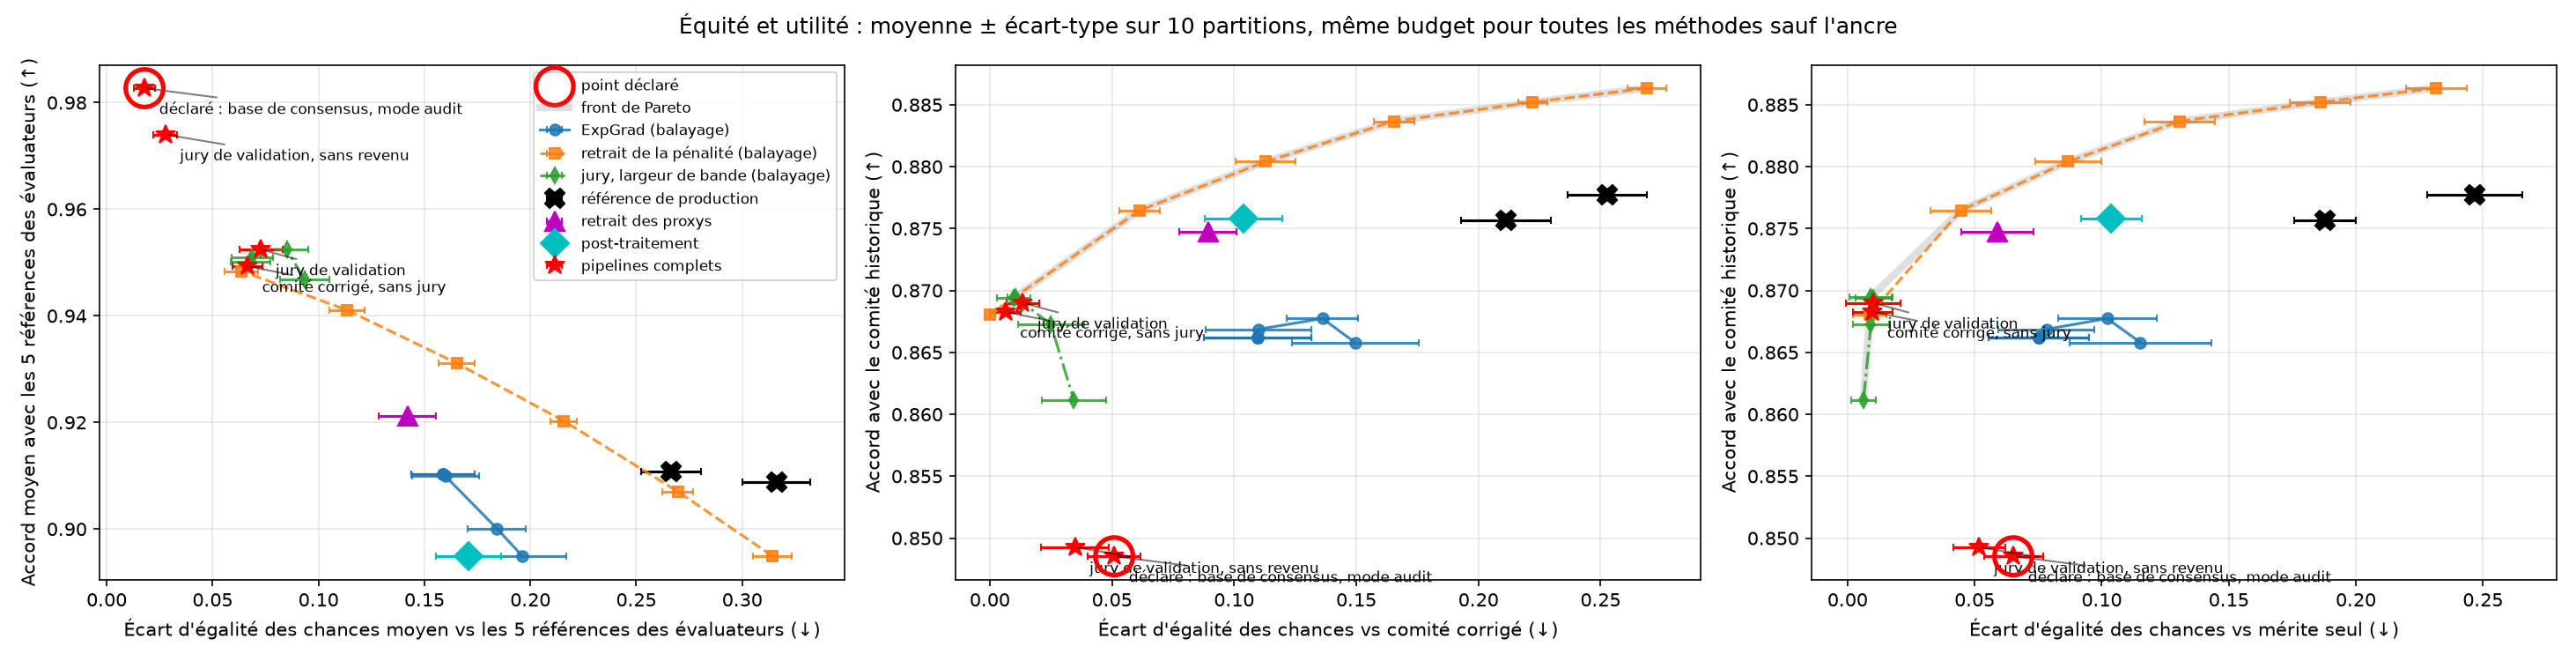

In [9]:
pareto = pd.read_csv('resultats_pareto.csv')
cols = ['method', 'rate_centre', 'rate_remote', 'eo_gap_reviewers_mean', 'agree_reviewers_mean', 'eo_gap_consensus', 'g_merit',
        'eo_gap_corrected', 'eo_gap_merit', 'acc_historical', 'pareto']
key = [m for m in pareto.method if m.startswith('declared') or m in ('validator jury', 'income-blind validator jury', 'committee-corrected, no jury', 'production RF at budget')]
print(pareto[pareto.method.isin(key)][cols].round(3).to_string(index=False))
print(f"\nPoints sur le front de Pareto principal : {', '.join(pareto[pareto.pareto].method)}")
display(Image('pareto_front.png'))

**L'accord avec le consensus du point déclaré est en partie circulaire** : il optimise la cible qu'on utilise pour le mesurer. D'où l'importance des cinq références prises séparément (accord moyen) et des limites déclarées de la garde du consensus.

## (f) Pistes rejetées

In [10]:
rejected = pd.DataFrame([
    ('Modèles plus gros, MLP', "La cible est un seuil linéaire : jurés entraînés AUC ≈ 1,0 sur l'étiquette, ils répètent le modèle principal (1 échange sur 293 révisions)."),
    ('Gros modèles contrefactuels sur les vraies décisions du comité', "Validation croisée 5 plis : aucun ne bat la régression logistique (perte log 0,2597 contre 0,2623 à 0,2734) ; le comité est linéaire."),
    ('Axes « mérite » / « effort »', "Reparamétrage d'une même régression (coefficients implicites 9,504 / 1,382 contre 9,506 / 1,382 ; Δp max 5e-4)."),
    ('« Plan équitable » (projection sur le noyau)', "Retire surtout les heures (u : R −0,144, revenu −0,465, heures +0,874) ; accord avec les étiquettes 0,997 → 0,974."),
    ('Harnais par étapes (stepwise) et veto à double jury', "Écartés : complexité supplémentaire sans gain démontré sur l'historique ; code retiré de la version publiée."),
    ('Ancien jury validateur', "35 échanges : écart EO de 0,002 à 0,016 (désormais bloqué par la garde du consensus)."),
    ("Seuil d'heures à 10 h", "Non identifié (retenu dans 48 % des rééchantillonnages) ; remplacé par un crédit linéaire."),
], columns=['Piste', 'Preuve du rejet'])
for _, r in rejected.iterrows():
    print(f"- {r['Piste']}\n    {r['Preuve du rejet']}")

- Modèles plus gros, MLP
    La cible est un seuil linéaire : jurés entraînés AUC ≈ 1,0 sur l'étiquette, ils répètent le modèle principal (1 échange sur 293 révisions).
- Gros modèles contrefactuels sur les vraies décisions du comité
    Validation croisée 5 plis : aucun ne bat la régression logistique (perte log 0,2597 contre 0,2623 à 0,2734) ; le comité est linéaire.
- Axes « mérite » / « effort »
    Reparamétrage d'une même régression (coefficients implicites 9,504 / 1,382 contre 9,506 / 1,382 ; Δp max 5e-4).
- « Plan équitable » (projection sur le noyau)
    Retire surtout les heures (u : R −0,144, revenu −0,465, heures +0,874) ; accord avec les étiquettes 0,997 → 0,974.
- Harnais par étapes (stepwise) et veto à double jury
    Écartés : complexité supplémentaire sans gain démontré sur l'historique ; code retiré de la version publiée.
- Ancien jury validateur
    35 échanges : écart EO de 0,002 à 0,016 (désormais bloqué par la garde du consensus).
- Seuil d'heures à 10 h
    Non i

## (g) Limites

- **Référence cachée inconnue.** Les « méritants » sont des hypothèses issues des examens ; l'accord avec les cinq règles est un substitut, non une mesure.
- **Désaccord sur le revenu.** Mérite, juridique, régional : 0 ; besoin : −0,05 ; processus de données : +0,19. Le poids déclaré (+0,025) et le mélange du résidu (2,5) sont des choix de modélisation déclarés, retenus par essais, à faire valider par un comité humain.
- **Le résidu TabM améliore la perte logarithmique historique de façon minime** (voir `models/tabm_residual_ensemble_rh/manifest.json`) : l'étiquette historique mesure les décisions du comité, pas le mérite.
- **Données synthétiques** ; pénalité estimée sur l'historique, à ré-estimer à chaque cycle ; le modèle du comité est logistique, pas le comité réel.
- Fondements juridiques (Charte québécoise art. 10, 86 ; Loi 25 art. 12.1) à vérifier avant citation.

In [11]:
print(f"Durée totale : {time.time() - T0:.0f} s")

Durée totale : 7 s
